# ARIMA Time-Series Modelling and Forecasting

## A Fully Annotated Python Tutorial Using Monthly Hot Dog Sales

### Purpose of the Notebook

This notebook provides an educational and fully annotated introduction to ARIMA time-series modelling in Python. The hot dog sales data are used as a simple illustrative example, while the primary focus is on explaining the statistical reasoning, mathematical foundations, model estimation and evaluation process in both technical and natural language.

The analysis demonstrates how to:

* prepare and visualise time-series data;
* examine stationarity using rolling statistics, the ADF test and the KPSS test;
* apply differencing to transform a non-stationary series;
* explain the AR and MA components of an ARIMA model;
* use the ACF and PACF to identify possible values of $p$ and $q$;
* estimate an ARIMA model and produce point forecasts and forecast intervals;
* examine model residuals;
* perform automated model selection using AIC;
* evaluate forecasting accuracy on a chronological test period using ME, MAE, MSE, RMSE and MAPE.

### Data

The dataset contains monthly hot dog sales observations from January 2021 to October 2024. The time variable is `trx_month`, while the target variable is `hot_dog_sales_pcs`, which records the number of hot dogs sold during each month.

The dataset is intentionally simple so that the statistical concepts and the complete ARIMA modelling process can be presented clearly.

### Running the Notebook

Place the dataset in the `data` folder and run the notebook cells sequentially from top to bottom. The analysis requires Python, Jupyter Notebook and the packages listed below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
file_path = r"C:\Users\Balazs\OneDrive - elte.hu\Desktop\python_mat\11_óra\ora11-hw2.csv"

In [3]:
df = pd.read_csv(file_path)

df.head(25)

,station_id,trx_month,hot_dog_sales_pcs
0,station_007,1/1/2021,2014
1,station_007,2/1/2021,1870
2,station_007,3/1/2021,1819
3,station_007,4/1/2021,1860
4,station_007,5/1/2021,2319
5,station_007,6/1/2021,2518
6,station_007,7/1/2021,2219
7,station_007,8/1/2021,2201
8,station_007,9/1/2021,2079
9,station_007,10/1/2021,2204


In [4]:
# Convert the transaction month column to datetime format
df['trx_month'] = pd.to_datetime(df['trx_month'], format='%m/%d/%Y')


# Sort the observations chronologically
df = df.sort_values('trx_month')


# Set the transaction month as the time-series index
df.set_index('trx_month', inplace=True)


# Select the hot dog sales variable as the time series to be analysed
hot_dog_sales_ts = df['hot_dog_sales_pcs']

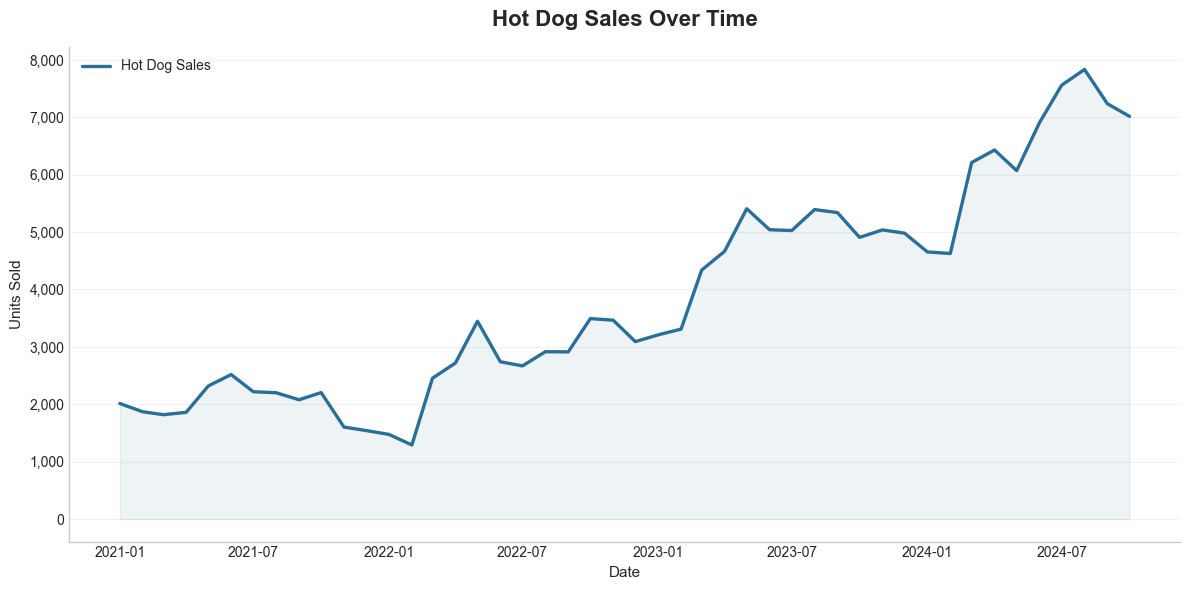

In [8]:
from matplotlib.ticker import StrMethodFormatter
# Apply a clean and consistent visual style
plt.style.use('seaborn-v0_8-whitegrid')


# Plot the time series to identify trends, fluctuations, and possible seasonal patterns
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hot_dog_sales_ts,
    label='Hot Dog Sales',
    color='#2A6F97',
    linewidth=2.4
)

# Add subtle shading to improve visual emphasis
ax.fill_between(
    hot_dog_sales_ts.index,
    hot_dog_sales_ts.values,
    color='#2A6F97',
    alpha=0.08
)

ax.set_title(
    'Hot Dog Sales Over Time',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units Sold', fontsize=11)

# Format large values with thousands separators
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

The figure shows an overall upward trend in hot dog sales, although short-term fluctuations are also visible. This indicates that sales generally increased over the observed period, but it does not necessarily mean that demand rose continuously. To prepare the data for time-series analysis, the date variable was converted to datetime format, the observations were arranged chronologically, and the date variable was set as the index.


## Stationarity Assessment and Transformation

In this chaper the stationarity of the hot dog sales time series is evaluated using graphical diagnostics and complementary statistical tests, including the Augmented Dickey–Fuller (ADF) and KPSS tests. If the original series is found to be non-stationary (as expected) an appropriate transformation, such as differencing, is applied.

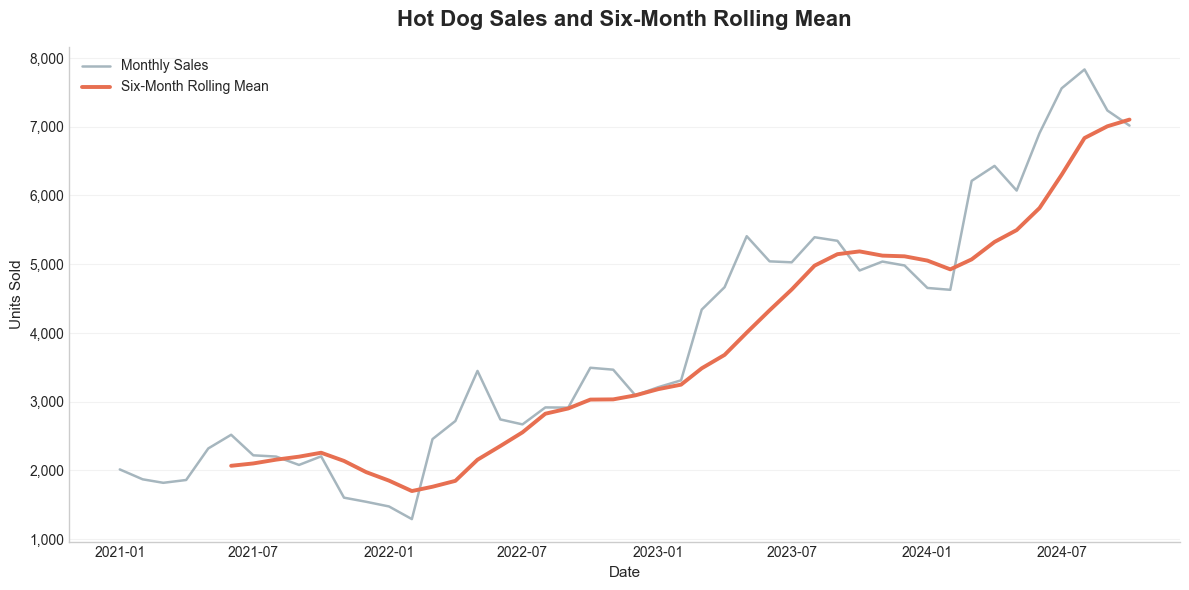

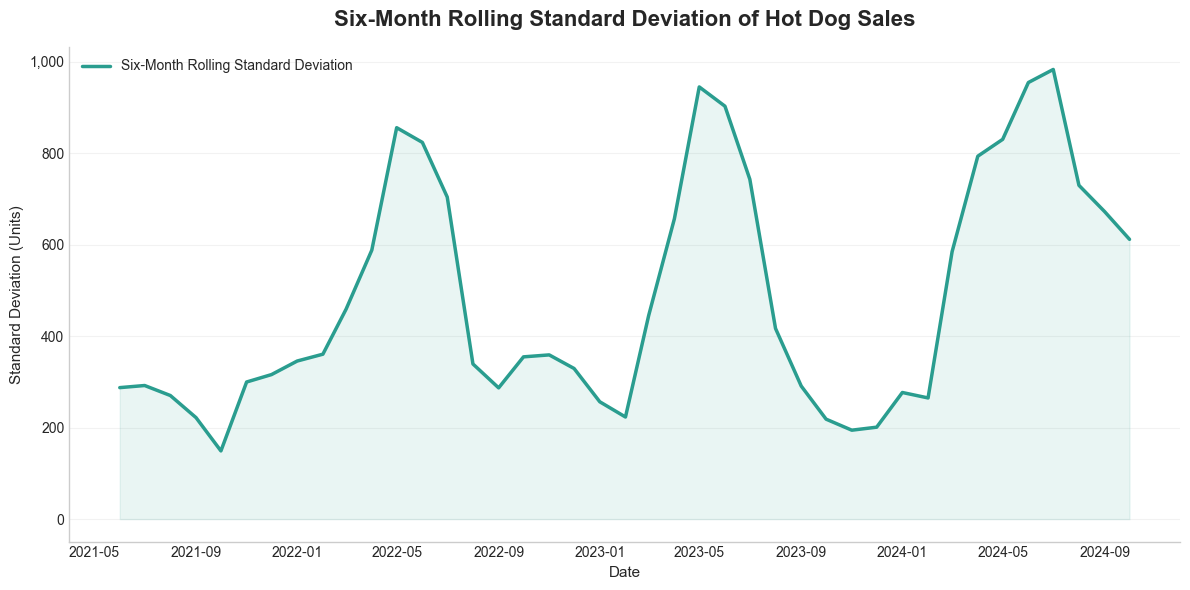

In [9]:
# Calculate the six-month rolling mean
rolling_mean = df['hot_dog_sales_pcs'].rolling(window=6).mean()


# Calculate the six-month rolling standard deviation
rolling_std = df['hot_dog_sales_pcs'].rolling(window=6).std()


# Visualise the original time series and its rolling mean
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df.index,
    df['hot_dog_sales_pcs'],
    label='Monthly Sales',
    color='#90A4AE',
    linewidth=1.8,
    alpha=0.8
)

ax.plot(
    df.index,
    rolling_mean,
    label='Six-Month Rolling Mean',
    color='#E76F51',
    linewidth=2.8
)

ax.set_title(
    'Hot Dog Sales and Six-Month Rolling Mean',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units Sold', fontsize=11)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


# Visualise the rolling standard deviation
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df.index,
    rolling_std,
    label='Six-Month Rolling Standard Deviation',
    color='#2A9D8F',
    linewidth=2.5
)

ax.fill_between(
    df.index,
    rolling_std.values,
    color='#2A9D8F',
    alpha=0.10
)

ax.set_title(
    'Six-Month Rolling Standard Deviation of Hot Dog Sales',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Standard Deviation (Units)', fontsize=11)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

***Stationarity***

The six-month rolling mean increases substantially over time, indicating that the mean of the series is not constant. The rolling standard deviation  fluctuates considerably, with repeated peaks suggesting changes in variability and a possible seasonal pattern. A series like this cannot be analysed reliably with models that assume stable patterns, because relationships learned from earlier observations may no longer describe later ones. Therefore, we first have to transform the data into a stationary series.

*Stationarity* means that the statistical properties of a time series remain stable over time. The individual observations may fluctuate, but the probabilistic rules behind those fluctuations should not change.

There are different types of stationarity, but in this project we use **weak stationarity**, also called **covariance stationarity**. This is the form required for the stationary ARMA component of an ARIMA model. A time series is weakly stationary if:

$$
E(X_t)=\mu,
$$

$${Var}(X_t)=\sigma^2,$$

and

$$
{Cov}(X_t,X_{t-h})=\gamma(h).
$$

where:

* $X_t$ is the value of the time series at time \(t\);
* $t$ is the time index, such as a particular month;
* $E(X_t)$ is the theoretical expected value of the series at time \(t\);
* $\mu$ is the constant theoretical mean of the series;
* ${Var}(X_t)$ is the variance of the series at time \(t\);
* $\sigma^2$ is the constant theoretical variance;
* ${Cov}(X_t,X_{t-h})$ is the covariance between two observations separated by \(h\) periods;
* $h$ is the lag, or the number of periods between two observations;
* $\gamma(h)$ is the autocovariance at lag \(h\).

The first condition means that the **theoretical expected value** is the same at every point in time. The second means that the variability of the series does not systematically increase or decrease. The third means that the relationship between two observations depends only on the distance between them, denoted by the lag $h$, and not on their exact position in calendar time.

As an imaginary example, suppose that a fair coin is tossed at every time point and $X_t=1$ for heads and $X_t=0$ for tails. The observed series may be:

$$
1,\ 0,\ 1,\ 1,\ 0,\ldots
$$

Nevertheless, at every time point:

$$
E(X_t)=0.5,
\qquad
\operatorname{Var}(X_t)=0.5(1-0.5)=0.25.
$$

Here, $0.5$ is the probability of obtaining heads. Because the possible outcomes are generated using the same probabilities at every time point, both the expected value and the variance remain constant.

If the coin tosses are independent, then:

$$
\operatorname{Cov}(X_t,X_{t-h})=0
\qquad \text{for } h\neq0.
$$

Here, $h\neq0$ means that we compare observations from different time points. Their covariance is zero because the result of one coin toss does not influence the result of another toss.

The observations change, but their mean, variance and covariance structure remain stable. Therefore, this process is weakly stationary.

By contrast, consider a time series with a deterministic trend:

$$
X_t=\alpha+\beta t+\varepsilon_t.
$$

where:

* $\alpha$ is the intercept or starting level of the series;
* $\beta$ is the average change in $X_t$ associated with a one-period increase in time;
* $\varepsilon_t$ is the random error or unpredictable shock at time $t$.

If the random error has an expected value of zero, the expected value of the series is:

$$
E(X_t)=\alpha+\beta t.
$$

If $\beta\neq0$, the expected value changes over time, so the process is not stationary. In the hot dog sales series, the six-month rolling mean increases substantially over time, which provides evidence against a constant mean. The changing rolling standard deviation also suggests that the variance may not be stable. However, rolling statistics are only sample-based visual diagnostics and therefore cannot formally establish non-stationarity. Consequently, we also have to use statistical tests to examine whether the series is stationary.

**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Section 1.3.2, pp. 16–18. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 4.1, pp. 15–17.


**Augmented Dickey–Fuller test and KPSS test**


The ADF and KPSS tests examine whether a time series is stationary, but use opposite null hypotheses: the ADF test assumes non-stationarity, while the KPSS test assumes stationarity.


In [10]:
# Augmented Dickey–Fuller test
# The test returns its results as a tuple
adf_result = adfuller(hot_dog_sales_ts, autolag='AIC')


# Define the significance level
significance_level = 0.05


print(f'ADF statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print('Critical values:')

for significance, critical_value in adf_result[4].items():
    print(f'  {significance}: {critical_value:.3f}')


# Evaluate the ADF test result
if adf_result[1] < significance_level:
    print('ADF conclusion: Reject H₀. The series is stationary.')
else:
    print(
        'ADF conclusion: Do not reject H₀. '
        'There is insufficient evidence of stationarity.'
    )


# KPSS test
kpss_statistic, kpss_p_value, kpss_lags, kpss_critical_values = kpss(
    hot_dog_sales_ts,
    regression='c',
    nlags='auto'
)


print(f'\nKPSS statistic: {kpss_statistic:.4f}')
print(f'p-value: {kpss_p_value:.4f}')
print('Critical values:')

for significance, critical_value in kpss_critical_values.items():
    print(f'  {significance}: {critical_value:.3f}')

print(f'Number of lags: {kpss_lags}')


# Evaluate the KPSS test result
if kpss_p_value < significance_level:
    print('KPSS conclusion: Reject H₀. The series is not stationary.')
else:
    print(
        'KPSS conclusion: Do not reject H₀. '
        'There is insufficient evidence against stationarity.'
    )

ADF statistic: 1.3648
p-value: 0.9969
Critical values:
  1%: -3.627
  5%: -2.946
  10%: -2.612
ADF conclusion: Do not reject H₀. There is insufficient evidence of stationarity.

KPSS statistic: 0.9510
p-value: 0.0100
Critical values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
Number of lags: 4
KPSS conclusion: Reject H₀. The series is not stationary.


C:\Users\Balazs\AppData\Local\Temp\ipykernel_15884\3256393887.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_statistic, kpss_p_value, kpss_lags, kpss_critical_values = kpss(


### Augmented Dickey–Fuller Test

The Augmented Dickey–Fuller (ADF) test examines whether a time series contains a **unit root**, which would indicate non-stationarity. The test can be derived from a simple autoregressive process:

$X_t=\rho X_{t-1}+\varepsilon_t.$

where:

* $X_{t-1}$ is the value of the series in the previous period;
* $\rho$ is the autoregressive coefficient, which measures how strongly the previous value influences the current value.

If $\rho=1$, the effects of previous shocks remain permanently in the series. This is called a **unit root** and indicates non-stationarity.

Subtracting $X_{t-1}$ from both sides gives:

$X_t-X_{t-1}=(\rho-1)X_{t-1}+\varepsilon_t.$

Because

$\Delta X_t=X_t-X_{t-1}$

and

$\gamma=\rho-1,$

the equation can be written as:

$\Delta X_t=\gamma X_{t-1}+\varepsilon_t.$

where:

* $\Delta$ is the difference operator, so $\Delta X_t$ is the change in the series between periods $t-1$ and $t$;
* $\gamma$ is the coefficient used to test whether the autoregressive coefficient $\rho$ equals one.

The $\gamma$ used here is not the same as the previously defined $\gamma(h)$, which represents the autocovariance at lag $h$.

The augmented version also includes lagged differences:

$\Delta X_t=\alpha+\gamma X_{t-1}+\sum_{i=1}^{p}\delta_i\Delta X_{t-i}+\varepsilon_t.$

where:

* $\sum$ indicates that several terms are added together;
* $p$ is the number of lagged differences included in the test;
* $i$ identifies the individual lag, from $1$ to $p$;
* $\delta_i$ is the coefficient of the $i$-th lagged difference;
* $\Delta X_{t-i}$ is the change in the series observed $i$ periods before time $t$.

These additional lagged differences account for autocorrelation in the series. In the Python code, `autolag='AIC'` automatically selects the number of lags using the Akaike Information Criterion, which balances model fit against model complexity.

The hypotheses of the ADF test are:

$H_0:\gamma=0\Longleftrightarrow\rho=1,$

and

$H_1:\gamma<0.$

where:

* $H_0$ is the null hypothesis;
* $H_1$ is the alternative hypothesis;
* $\Longleftrightarrow$ means that the two statements are mathematically equivalent.

Under $H_0$, the series contains a unit root and is non-stationary. Under $H_1$, the influence of previous shocks gradually disappears and the series returns towards a stable level.

The decision can be made using either the p-value or the critical values. The p-value indicates how compatible the observed result is with the null hypothesis. It should not be confused with the lag-order parameter $p$ in the ADF equation.

* If the p-value is below $0.05$, reject $H_0$.
* If the p-value is at least $0.05$, do not reject $H_0$.
* Equivalently, using the critical-value approach, reject $H_0$ if the ADF statistic is more negative than the selected critical value.

**Interpretation of the ADF output**

The project produced the following results:

$\text{ADF statistic}=1.3648,\qquad \text{p-value}=0.9969.$

At the $5$% significance level, the critical value is:

$-2.946.$

The observed ADF statistic is not more negative than the critical value:

$1.3648>-2.946.$

In addition, the p-value is substantially greater than $0.05$:

$0.9969>0.05.$

Therefore, the null hypothesis cannot be rejected. This does not mathematically prove that the series is non-stationary; rather, it means that the test provides no evidence against the presence of a unit root. Consequently, the original hot dog sales series should be treated as non-stationary.

**References:** Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 4.1, pp. 16–18. Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 9.3.1–9.3.2, pp. 306–316.






### KPSS Test

The KPSS test examines stationarity from the opposite direction. While the ADF test assumes non-stationarity under its null hypothesis, the KPSS test assumes that the series is stationary.

Because the code uses `regression='c'`, the test specifically examines **level stationarity**, meaning stationarity around a constant mean. In this setting, `c` indicates that the test equation contains a constant but no deterministic time trend.

The hypotheses are:

$H_0:\text{the series is level-stationary},$

and

$H_1:\text{the series is not level-stationary}.$

The test first removes the estimated constant mean from the series. The residual at time $t$ is:

$\hat{e}_t=X_t-\bar{X}.$

where:

* $\hat{e}_t$ is the estimated residual at time $t$;
* the hat symbol $\hat{\phantom{e}}$ indicates an estimated value;
* $\bar{X}$ is the sample mean of the observed time series.

The residuals are then accumulated:

$S_t=\sum_{j=1}^{t}\hat{e}_j.$

where:

* $S_t$ is the cumulative sum of the residuals up to time $t$;
* $j$ is the summation index identifying each residual included in the cumulative sum.

The ***KPSS*** statistic is calculated as:

$\operatorname{KPSS}=\frac{1}{T^2\hat{\sigma}_{LR}^{\,2}}\sum_{t=1}^{T}S_t^2.$

where:

* $T$ is the total number of observations;
* $\hat{\sigma}_{LR}^{,2}$ is the estimated long-run variance, adjusted for autocorrelation;
* $LR$ stands for *long run*.

If the series is stationary, positive and negative residuals tend to offset each other, so the cumulative sum $S_t$ remains relatively close to zero. If the series is non-stationary, the residuals may accumulate persistently in one direction, producing a large KPSS statistic.

The decision rule is:

* If the p-value is below $0.05$, reject $H_0$ and conclude that the series is not stationary.
* If the p-value is at least $0.05$, do not reject $H_0$.
* Equivalently, using the critical-value approach, reject $H_0$ if the KPSS statistic is greater than the selected critical value.

**Interpretation of the KPSS output**

The project produced:

$\text{KPSS statistic}=0.9510,\qquad \text{p-value}=0.0100.$

At the $5$% significance level, the critical value is:

$0.463.$

The observed statistic is greater than this critical value:

$0.9510>0.463.$

It is even greater than the $1$% critical value:

$0.9510>0.739.$

Therefore, the null hypothesis of level stationarity is rejected. The reported p-value of $0.0100$ is the lower boundary of the table used by the test, so the actual p-value may be smaller. The result provides strong evidence that the hot dog sales series is not level-stationary.

The reported number of lags is four which are used to estimate the long-run variance while accounting for autocorrelation. They do not mean that the final ARIMA model must contain four autoregressive terms.

**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 3.1.2–3.1.3, pp. 72–79, and Section 9.3.3, pp. 316–318.



**Combined Interpretation of ADF and KPSS**

The two tests start from opposite null hypotheses but reach the same substantive conclusion:

* The ADF test does not reject its null hypothesis of a unit root.
* The KPSS test rejects its null hypothesis of level stationarity.

Together with the increasing rolling mean, these results provide consistent evidence that the original hot dog sales series is non-stationary. The next step is therefore to apply first-order differencing:

$\Delta X_t=X_t-X_{t-1}.$


### First-Order Differencing

Because the ADF and KPSS tests indicated that the original hot dog sales series is non-stationary, the original values cannot be used directly in the stationary component of the ARIMA model. A common way to remove the changing level or trend is **differencing**, which replaces the original observations with their changes from one period to the next.

The first difference is calculated as:

$\Delta X_t=X_t-X_{t-1}.$

Instead of modelling the number of hot dogs sold in each month, the differenced series shows how much sales increased or decreased compared with the previous month. For example, if three consecutive observations are $2000$, $2200$ and $2500$, their first differences are $200$ and $300$.

The code applies this transformation:


Here, `hot_dog_sales_ts` is the original series, while `differenced_sales_ts` stores the monthly changes. The `.diff()` method subtracts the previous observation from the current observation, and `.dropna()` removes the first missing value. This missing value appears because the first observation has no previous value from which a difference could be calculated.

**The parameter $d$ in an ARIMA model records how many rounds of differencing are required to make the series stationary:**

* $d=0$: the original series is already stationary, so no differencing is required;
* $d=1$: the original series is non-stationary, but its first differences are stationary;
* $d=2$: the first-differenced series is still non-stationary, but its second differences are stationary.

Second-order differencing means taking the difference of the first differences:

$\Delta^2X_t=\Delta X_t-\Delta X_{t-1}=X_t-2X_{t-1}+X_{t-2}.$

where:

* $\Delta^2X_t$ is the second-order difference at time $t$;
* $X_{t-2}$ is the value of the original series two periods before time $t$.

The value of $d$ is therefore not selected in advance. It is determined by applying differencing step by step and testing stationarity after each transformation. The aim is to use the smallest value of $d$ that produces a stationary series.

In this project, the original series is non-stationary, so $d=0$ is not appropriate. We therefore apply first-order differencing and repeat the ADF and KPSS tests on the transformed series. If the first-differenced series is stationary, then $d=1$ is confirmed. Only in cases in which the time series remains non-stationary should second-order differencing and $d=2$ be considered. but in our case the appropriate differencing order in the ARIMA model is:

$d=1.$

where $d$ is the number of times the original series is differenced, so $d=1$ means that first-order differencing is applied once.

Using more differencing than necessary should be avoided because **over-differencing** can remove meaningful information, increase random noise and make the resulting model unnecessarily unstable.

**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 3.1.1–3.1.2, pp. 71–73. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Sections 4.1–4.2, pp. 17–19.




In [18]:
# Apply first-order differencing
differenced_sales_ts = hot_dog_sales_ts.diff().dropna()


# Augmented Dickey–Fuller test on the differenced series
adf_diff_result = adfuller(
    differenced_sales_ts,
    autolag='AIC'
)

print('ADF test for the first-differenced series')
print(f'ADF statistic: {adf_diff_result[0]:.4f}')
print(f'p-value: {adf_diff_result[1]:.4f}')
print('Critical values:')

for significance_level, critical_value in adf_diff_result[4].items():
    print(f'  {significance_level}: {critical_value:.3f}')

if adf_diff_result[1] < 0.05:
    print('ADF conclusion: Reject H₀. The differenced series is stationary.')
else:
    print(
        'ADF conclusion: Do not reject H₀. '
        'There is insufficient evidence of stationarity.'
    )


# KPSS test on the differenced series
kpss_diff_result = kpss(
    differenced_sales_ts,
    regression='c',
    nlags='auto'
)

print('\nKPSS test for the first-differenced series')
print(f'KPSS statistic: {kpss_diff_result[0]:.4f}')
print(f'p-value: {kpss_diff_result[1]:.4f}')
print('Critical values:')

for significance_level, critical_value in kpss_diff_result[3].items():
    print(f'  {significance_level}: {critical_value:.3f}')

print(f'Number of lags: {kpss_diff_result[2]}')

if kpss_diff_result[1] < 0.05:
    print('KPSS conclusion: Reject H₀. The differenced series is not stationary.')
else:
    print(
        'KPSS conclusion: Do not reject H₀. '
        'The differenced series can be treated as stationary.'
    )

ADF test for the first-differenced series
ADF statistic: -4.3276
p-value: 0.0004
Critical values:
  1%: -3.627
  5%: -2.946
  10%: -2.612
ADF conclusion: Reject H₀. The differenced series is stationary.

KPSS test for the first-differenced series
KPSS statistic: 0.1143
p-value: 0.1000
Critical values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
Number of lags: 3
KPSS conclusion: Do not reject H₀. The differenced series can be treated as stationary.


C:\Users\Balazs\AppData\Local\Temp\ipykernel_6464\2906024708.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff_result = kpss(


**Since our model became stationary after the  first-differenced series we can move on  to the next chapter**

### The AR and MA Components of ARIMA

After differencing has produced a stationary series, the ARIMA model can describe the remaining temporal relationships using two main components: the **autoregressive component** and the **moving-average component**. To distinguish the stationary series used by the model from the original series, we denote it by $W_t$.

where:

* $W_t$ is the stationary value modelled at time $t$; it may represent either the original series or a differenced version of it.

### Autoregressive Component

The **autoregressive component**, abbreviated as **AR**, uses previous values of the stationary series to explain or predict its current value. In simple terms, it asks whether knowing the value from the previous period helps us predict the current value.

A first-order autoregressive model can be written around the constant mean as:

$W_t-\mu=\phi(Y_{t-1}-\mu)+\varepsilon_t.$

where:

* $W_{t-1}$ is the stationary value observed in the previous period;
* $\phi$ is the autoregressive coefficient, which measures the direction and strength of the relationship between the previous and current values.

The coefficient $\phi$ shows how much of the previous deviation from the mean remains in the current period. For example, suppose that the long-term mean is $7000$, the previous value is $7500$ and $\phi=0.8$. The previous observation is therefore $500$ units above the mean:

$7500-7000=500.$

The model expects $80$% of this difference to remain in the next period:

$0.8\times500=400.$

Before the new random shock is observed, the predicted value is therefore:

$7000+400=7400.$

Because the previous value was above the long-term mean, the next value is also expected to remain above the mean. However, the difference becomes smaller, meaning that the series gradually moves back towards its stable level.

Now suppose that the **long-term mean is still $7000$, the previous value is $7500$, but the autoregressive coefficient is $\phi=-0.8$**. 
The previous value is again $500$ units above the mean:

$7500-7000=500.$

The predicted deviation from the mean is now:

$-0.8\times500=-400.$

Therefore, before the new random shock is observed, the predicted value is:

$7000-400=6600.$

Because the coefficient is negative, an observation above the mean is expected to be followed by an observation below the mean. If no new shock occurs, the following predicted deviation is:

$-0.8(-400)=320,$

which produces a predicted value of:

$7000+320=7320.$

The values therefore alternate between the two sides of the long-term mean.

**NOTE:**

*The coefficients are generally estimated using maximum likelihood estimation. The algorithm begins with initial candidate values for $c$, $\phi_1$, and $\theta_1$. Using these values, it calculates the predicted change at each time point:*

$\hat{W}_t=c+\phi_1W_{t-1}+\theta_1\hat{\varepsilon}_{t-1}.$

*The corresponding prediction error is then:*

*$\hat{\varepsilon}_t=W_t-\hat{W}_t.$*

*The hat symbol indicates an estimated or predicted quantity. The algorithm repeatedly changes the coefficient values and recalculates the predictions and errors. It continues until it finds the values that make the observed time series most likely under the assumed model.*

*For example, the estimated coefficients of a hypothetical ARIMA$(1,1,1)$ model might be:*

*$\hat{c}=80,\qquad \hat{\phi}_1=0.45,\qquad \hat{\theta}_1=-0.30.$*

*If hot dog sales increased by $W_{t-1}=200$ units in the previous month and the previous prediction error was $\hat{\varepsilon}_{t-1}=50$, the predicted current change would be:*

*$\hat{W}_t=80+0.45(200)-0.30(50)=155.$*
### Moving-Average Component

The **moving-average component**, abbreviated as **MA**, uses previous random shocks or forecast errors to explain the current value. It asks whether an unexpected forecasting error in an earlier period continues to influence the series in the current period.

The term **moving average** in an ARIMA model should not be confused with a rolling arithmetic average because it refers to a weighted combination of current and previous forecast errors.

A first-order moving-average model can be written as:

$W_t=\mu+\varepsilon_t+\theta\varepsilon_{t-1}.$

where:

* $\varepsilon_{t-1}$ is the random shock or forecast error from the previous period;
* $\theta$ is the moving-average coefficient, which measures how strongly the previous error influences the current value.

Suppose that the stable mean is $100$, the current random shock is $\varepsilon_t=2$, the previous forecast error is $\varepsilon_{t-1}=-4$ and $\theta=0.7$. The current value is:

$W_t=100+2+0.7(-4)=99.2.$

The previous error contributes:

$0.7(-4)=-2.8.$

The current positive shock contributes $2$, but it does not fully offset the negative effect carried over from the previous period. Consequently, the resulting value is slightly below the stable mean.

The model remembers that the previous prediction was too high because the observed value was $4$ units below the forecast. A proportion of that previous error is therefore included when modelling the current value.

Suppose that the stable mean is still $100$, the current shock is $\varepsilon_t=2$, the previous forecast error is $\varepsilon_{t-1}=-4$, but the moving-average coefficient is $\theta=-0.8$. The current value is:

$W_t=100+2+(-0.8)(-4)=105.2.$

The previous negative error contributes:

$(-0.8)(-4)=3.2.$

The negative moving-average coefficient reverses the direction of the previous error. Therefore, the previous negative error has a positive effect on the current value. Together with the current positive shock of $2$, this raises the current value to $105.2$, which is above the stable mean.



### The Three ARIMA Parameters

An ARIMA model is written as $\operatorname{ARIMA}(p,d,q)$, where:

* $p$ is the number of previous values included in the autoregressive component;
* $d$ is the number of times the original series is differenced to achieve stationarity;
* $q$ is the number of previous forecast errors included in the moving-average component.


The AR and MA components can be combined after the necessary differencing has been applied. To distinguish the original series from the transformed series, the stationary series is denoted by:

$W_t=\Delta^dX_t.$

In our case, $d=1$, so:

$W_t=\Delta^1X_t=\Delta X_t=X_t-X_{t-1}.$

Thus, $X_t$ represents the original sales level, while $W_t$ represents the change in sales compared with the previous period.

The complete ARIMA model can then be represented as:

$W_t=c+\sum_{i=1}^{p}\phi_iW_{t-i}+\varepsilon_t+\sum_{j=1}^{q}\theta_j\varepsilon_{t-j}.$

where:

$W_t$ is the stationary series obtained after differencing the original series $d$ times;
$c$ is the constant of the stationary ARMA equation; when $d=1$, it represents drift in the original series;
$W_{t-i}$ is the stationary value observed $i$ periods before time $t$;
$\phi_i$ is the autoregressive coefficient belonging to the $i$-th previous value;
$\varepsilon_{t-j}$ is the forecast error observed $j$ periods before time $t$;
$\theta_j$ is the moving-average coefficient belonging to the $j$-th previous error.

The parameters $p$ and $q$ determine how many AR and MA terms are included, but they do not determine the numerical values of the coefficients. The ACF and PACF plots provide initial guidance for selecting $p$ and $q$, while the values of $c$, $\phi_i$, and $\theta_j$ are estimated from the observed data, generally by maximum likelihood estimation.

For example, an ARIMA$(1,1,1)$ model contains one autoregressive term and one moving-average term:

$W_t=c+\phi_1W_{t-1}+\varepsilon_t+\theta_1\varepsilon_{t-1}.$

Because $W_t=\Delta X_t$ when $d=1$, this can also be written as:

$\Delta X_t=c+\phi_1\Delta X_{t-1}+\varepsilon_t+\theta_1\varepsilon_{t-1}.$

The algorithm begins with initial candidate values for $c$, $\phi_1$, and $\theta_1$. Using these values, it calculates the predicted monthly change:

$\hat{W}t=c+\phi_1W{t-1}+\theta_1\hat{\varepsilon}_{t-1},$

and the corresponding prediction error:

$\hat{\varepsilon}_t=W_t-\hat{W}_t.$

The hat symbol indicates an estimated or predicted quantity. The algorithm repeatedly changes the coefficient values and recalculates the predictions and errors until it finds the values that make the observed time series most likely under the model. These values are the maximum likelihood estimates.





**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 3.2.1, 3.3.1 and 3.4.1, pp. 80–100. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 4.2, pp. 18–20.


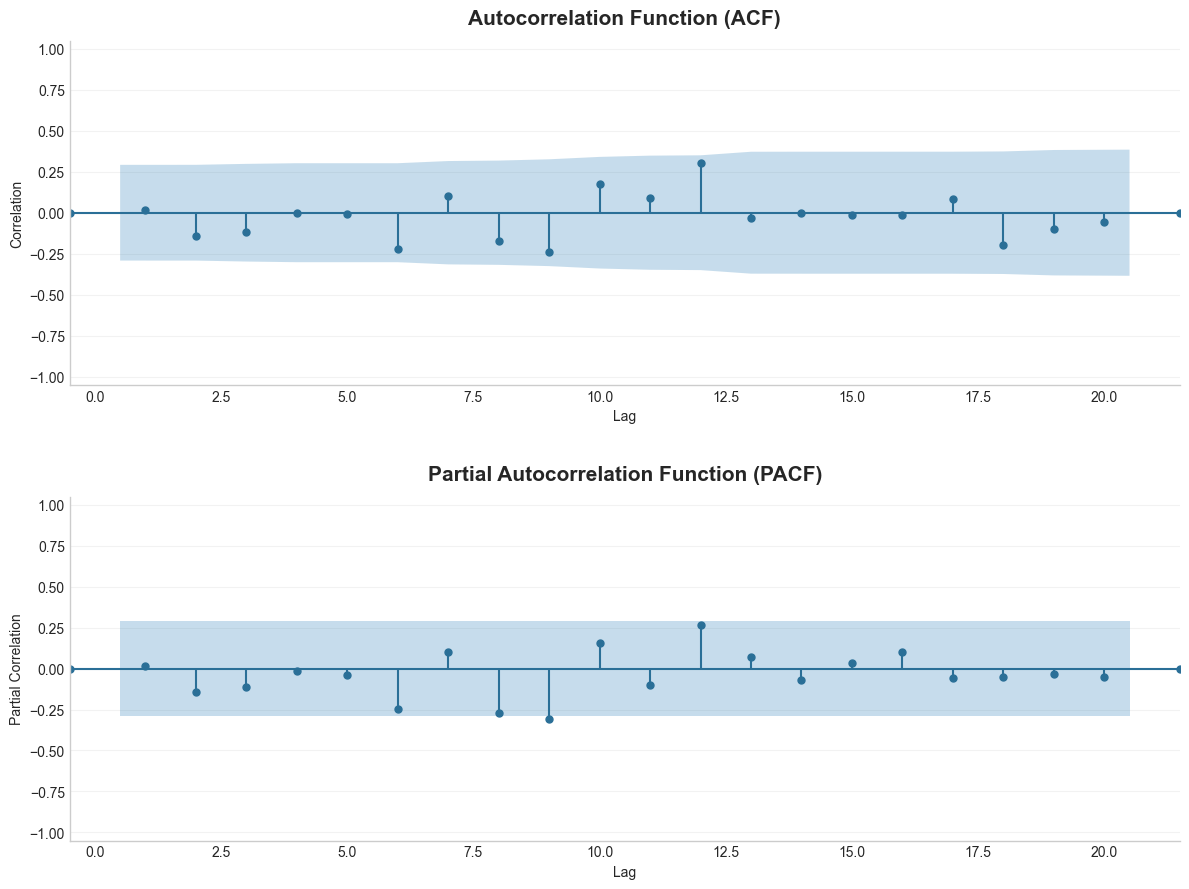

In [19]:
# Apply first-order differencing
#differenced_sales_ts = hot_dog_sales_ts.diff().dropna()


# Create separate panels for the ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(12, 9))


# Plot the ACF to examine correlations between observations and their lagged values
plot_acf(
    differenced_sales_ts,
    ax=axes[0],
    lags=20,
    zero=False,
    alpha=0.05,
    color='#2A6F97',
    marker='o',
    markersize=5,
    vlines_kwargs={
        'colors': '#2A6F97',
        'linewidth': 1.5
    }
)

axes[0].set_title(
    'Autocorrelation Function (ACF)',
    fontsize=15,
    fontweight='semibold',
    pad=12
)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')


# Plot the PACF to examine the direct relationship with each lag
plot_pacf(
    differenced_sales_ts,
    ax=axes[1],
    lags=20,
    zero=False,
    alpha=0.05,
    method='ywm',
    color='#2A6F97',
    marker='o',
    markersize=5,
    vlines_kwargs={
        'colors': '#2A6F97',
        'linewidth': 1.5
    }
)

axes[1].set_title(
    'Partial Autocorrelation Function (PACF)',
    fontsize=15,
    fontweight='semibold',
    pad=12
)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Correlation')


# Apply consistent formatting to both panels
for current_axis in axes:
    current_axis.set_ylim(-1.05, 1.05)
    current_axis.grid(axis='y', alpha=0.25, linewidth=0.8)
    current_axis.grid(axis='x', visible=False)
    current_axis.spines['top'].set_visible(False)
    current_axis.spines['right'].set_visible(False)
    current_axis.tick_params(axis='both', labelsize=10)

fig.align_ylabels(axes)
plt.tight_layout(h_pad=3)
plt.show()

### Determining $p$ and $q$ with the ACF and PACF

To determine the values of the $p$ and $q$ parameters, we examine two correlation functions calculated from the stationary series. As we will see **autocorrelation function (ACF)** provides initial guidance for selecting $q$, while the **partial autocorrelation function (PACF)** provides initial guidance for selecting $p$.

The ACF and PACF must be calculated after the necessary differencing has been applied. Otherwise, the trend in a non-stationary series may produce large and misleading autocorrelations.



### Autocorrelation Function

The **autocorrelation function**, abbreviated as **ACF**, measures the relationship between observations of the same series separated by a particular number of periods.

The theoretical autocorrelation at lag $h$ is:

$\rho(h)=\frac{\gamma(h)}{\gamma(0)}.$

where:

* $\rho(h)$ is the theoretical autocorrelation at lag $h$ (the $\rho(h)$ used here represents autocorrelation at a particular lag and **should not** be confused with the autoregressive coefficient $\rho$ used in the ADF test.);
* $\gamma(0)$ is the autocovariance at lag zero, which is equal to the variance of the stationary series.


Because the theoretical autocorrelation is unknown, it is estimated from the observed stationary series:

$\hat{\rho}_h=\frac{\sum_{t=1}^{T-h}(W_t-\bar{W})(W_{t+h}-\bar{W})}{\sum_{t=1}^{T}(W_t-\bar{W})^2}.$

where:

* $\hat{\rho}_h$ is the estimated sample autocorrelation at lag $h$;
* $\bar{W}$ is the sample mean of the stationary series;
* $W_{t+h}$ is the stationary value observed $h$ periods after time $t$.

The numerator measures whether observations separated by $h$ periods tend to move together. The denominator standardizes this joint movement by the total variability of the series. Therefore, the autocorrelation ranges between $-1$ and $1$.

* A positive autocorrelation means that positive changes tend to be followed by positive changes and negative changes by negative changes.
* A negative autocorrelation means that positive changes tend to be followed by negative changes, and vice versa.
* An autocorrelation close to zero means that there is no clear linear relationship at that lag.

For example, the ACF at lag $1$ measures the relationship between the current monthly change in hot dog sales and the change observed one month later. The ACF at lag $2$ compares monthly changes separated by two months.

**The shaded area around zero represents an approximately $95$% confidence interval. Under a simple white-noise assumption, a rough confidence interval is:**

$-\frac{1.96}{\sqrt{T}}\leq\text{correlation}\leq\frac{1.96}{\sqrt{T}}.$

Here, $1.96$ is the critical value associated with a $95$% normal confidence interval (The exact intervals calculated by the software may vary across lags because they can include additional adjustments).

* A spike outside the confidence interval indicates a statistically significant autocorrelation at that lag.
* A spike inside the confidence interval is not clearly different from zero.

The value of $q$ is initially determined from the ACF plot:

* $q=0$ if none of the first ACF lags are significant;
* $q=1$ if lag $1$ is significant but the following lags are approximately zero;
* $q=2$ if lags $1$ and $2$ are significant but the following lags are approximately zero;
* the same logic continues for higher values.

This pattern where the ACF is significant up to a particular lag and then becomes approximately zero, is called a **cut-off**. In a pure MA process, the ACF cuts off after lag $q$, while the PACF generally decreases gradually.

 ***Example: Hot Dog Sales***

In the ACF plot of the first-differenced hot dog sales series, the first autocorrelations remain inside the $95$% confidence interval. In particular, neither lag $1$ nor lag $2$ is statistically significant, and there is no clear cut-off pattern after the first few lags.

Some later autocorrelations are moderately positive or negative, but they also remain within the confidence interval. Therefore, they are not clearly different from zero and do not provide evidence of a systematic MA structure.

This means that previous forecast errors do not appear to help explain the current monthly change in hot dog sales. Based on the ACF plot, the initial moving-average order is:

$q=0.$


### Partial Autocorrelation Function

The **partial autocorrelation function**, abbreviated as **PACF**, measures the direct relationship between the current value and a previous value after removing the effects of the intermediate lags.

The PACF at lag $h$ can be estimated using a regression containing all previous values up to lag $h$:

$W_t=c+\phi_{h,1}W_{t-1}+\phi_{h,2}W_{t-2}+\cdots+\phi_{h,h}W_{t-h}+u_t.$

The partial autocorrelation at lag $h$ is the estimated coefficient of the final lag:

$\widehat{\operatorname{PACF}}(h)=\hat{\phi}_{h,h}.$

where:

* $\phi_{h,i}$ is the coefficient of the $i$-th lag in a regression containing all lags from $1$ to $h$;
* $u_t$ is the part of the current value that is not explained by the included previous values;
* $\hat{\phi}_{h,h}$ is the estimated effect of the final lag after controlling for all shorter lags.

For example, the ACF at lag $2$ measures the complete relationship between $W_t$ and $W_{t-2}$. However, $W_{t-2}$ may influence $W_{t-1}$, which then influences $W_t$. The PACF at lag $2$ removes the effect of $W_{t-1}$ and measures whether $W_{t-2}$ still has a direct relationship with $W_t$.

The same confidence-interval interpretation applies to the PACF plot:

* a spike outside the shaded area indicates a statistically significant partial autocorrelation;
* a spike inside the shaded area is not clearly different from zero.

The value of $p$ is initially determined from the PACF plot:

* $p=0$ if none of the first PACF lags are significant;
* $p=1$ if lag $1$ is significant but the following lags are approximately zero;
* $p=2$ if lags $1$ and $2$ are significant but the following lags are approximately zero;
* the same logic continues for higher values.

In a pure AR process, the PACF cuts off after lag $p$, while the ACF generally decreases gradually.

The value of $p$ should not automatically equal the largest lag containing any significant spike. A single significant spike at a distant lag does not necessarily represent a meaningful AR structure when the preceding lags do not show a coherent pattern.

***Example: Hot Dog Sales***

In the PACF plot of the first-differenced hot dog sales series, the first partial autocorrelations remain inside the $95$% confidence interval. Neither lag $1$ nor lag $2$ shows a statistically significant direct relationship with the current monthly change.

The PACF contains an isolated negative spike around lag $9$. However, lags $1$ to $8$ do not form a coherent sequence of significant partial autocorrelations. The spike at lag $9$ may therefore reflect random sampling variation rather than a meaningful ninth-order autoregressive structure. On its own, it is not sufficient evidence for selecting $p=9$.

Because the early PACF lags do not show a significant cut-off pattern, previous monthly changes do not appear to have a systematic direct effect on the current change. Based on the PACF plot, the initial autoregressive order is:

$p=0.$




### Resulting ARIMA Model

We have already concluded that the required order of differencing is:

$d=1.$

In the hot dog sales example, the PACF analysis did not identify a clear autoregressive structure in the differenced series, suggesting:

$p=0.$

Similarly, the ACF analysis did not identify a clear moving-average structure, suggesting:

$q=0.$

The three selected parameters are therefore:

$p=0,\qquad d=1,\qquad q=0.$

So the resulting baseline specification is:

$\operatorname{ARIMA}(0,1,0).$

Because $p=0$ and $q=0$, the model contains no AR or MA terms.

$W_t=\varepsilon_t.$

Since $d=1$:

$W_t=\Delta X_t.$

Here, $\Delta X_t$ denotes the first difference of the original series, meaning the change in hot dog sales between the current and previous month: $\Delta X_t=X_t-X_{t-1}$.

Therefore, the selected model can be written as:

$\Delta X_t=\varepsilon_t.$

Using the definition $\Delta X_t=X_t-X_{t-1}$ gives:

$X_t-X_{t-1}=\varepsilon_t,$

or:

$X_t=X_{t-1}+\varepsilon_t.$


Because $p=0$ and $q=0$, the model contains no AR or MA terms, and after first-order differencing, almost all ACF and PACF coefficients fall within the $95$% confidence intervals, indicating that the trend-related persistence has largely been removed, which means that the remaining monthly changes therefore behave approximately like random shocks.
therefore th model for the transformed series simplifies to:


**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Section 1.3.3, pp. 18–21, and Section 2.1, pp. 37–42. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Sections 4.1–4.2, pp. 15–19.


,Forecast,Lower 95% CI,Upper 95% CI
2024-11-01,7016.0,6073.0,7959.0
2024-12-01,7016.0,5683.0,8349.0
2025-01-01,7016.0,5383.0,8649.0


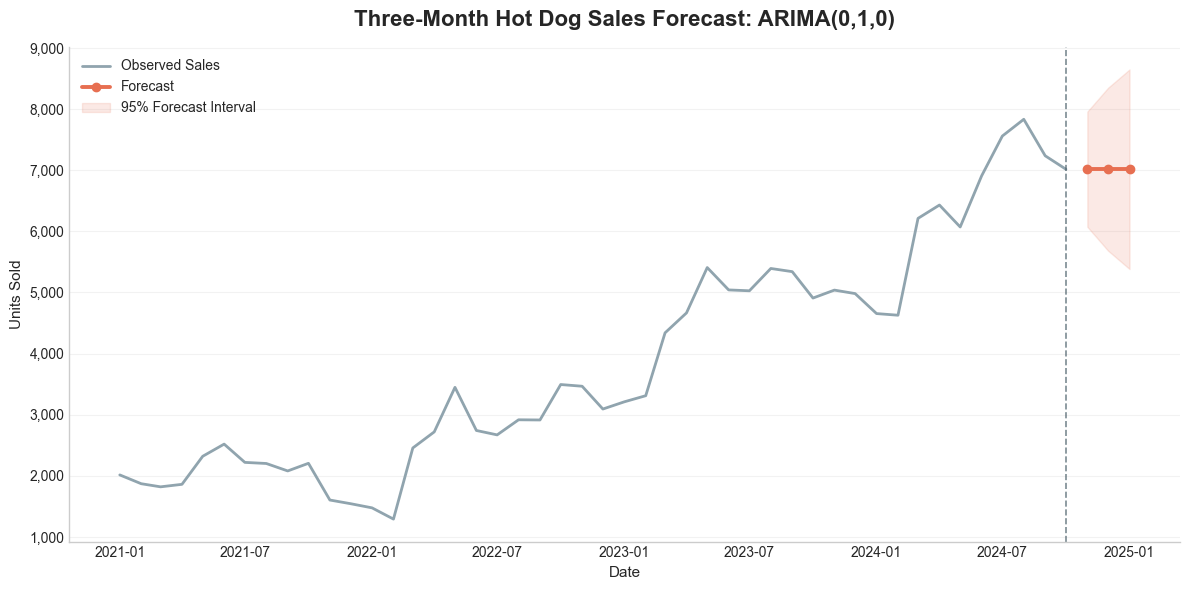

In [9]:
# Ensure that the time series has a regular monthly frequency
hot_dog_sales_ts = df['hot_dog_sales_pcs'].asfreq('MS')


# Define and estimate the ARIMA(0,1,0) model
model = ARIMA(
    hot_dog_sales_ts,
    order=(0, 1, 0)
)

model_fit = model.fit()


# Generate forecasts for the following three months
forecast_result = model_fit.get_forecast(steps=3)

forecast = forecast_result.predicted_mean
forecast_confidence_interval = forecast_result.conf_int(alpha=0.05)


# Create a table containing the point forecasts and confidence intervals
forecast_table = pd.DataFrame({
    'Forecast': forecast,
    'Lower 95% CI': forecast_confidence_interval.iloc[:, 0],
    'Upper 95% CI': forecast_confidence_interval.iloc[:, 1]
})

display(forecast_table.round(0))


# Visualise the historical observations and the three-month forecast
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hot_dog_sales_ts.index,
    hot_dog_sales_ts,
    label='Observed Sales',
    color='#90A4AE',
    linewidth=2
)

ax.plot(
    forecast.index,
    forecast.values,
    label='Forecast',
    color='#E76F51',
    linewidth=2.8,
    marker='o',
    markersize=6
)

# Display the uncertainty associated with the forecasts
ax.fill_between(
    forecast.index,
    forecast_confidence_interval.iloc[:, 0],
    forecast_confidence_interval.iloc[:, 1],
    color='#E76F51',
    alpha=0.15,
    label='95% Forecast Interval'
)

# Mark the point at which the forecast period begins
ax.axvline(
    hot_dog_sales_ts.index[-1],
    color='#455A64',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7
)

ax.set_title(
    'Three-Month Hot Dog Sales Forecast: ARIMA(0,1,0)',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units Sold', fontsize=11)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### ARIMA Model Estimation

Based on the stationarity tests and the ACF and PACF plots of the first-differenced series, $\operatorname{ARIMA}(0,1,0)$ is used as the baseline model. This specification applies first-order differencing but does not contain separate AR or MA terms.

The model can be expressed as:

$\Delta X_t=\varepsilon_t,$

or equivalently:

$X_t=X_{t-1}+\varepsilon_t.$

The current value equals the previous value plus a new unpredictable shock. This process is called a **random walk**. The original sales levels are non-stationary, but their monthly changes are assumed to behave like random errors.

The model does not contain a drift term. Because the expected value of the random shock is zero, the expected monthly change is also zero:

$E(\Delta X_t)=E(\varepsilon_t)=0.$

This does not mean that future sales cannot increase or decrease. It means that the model cannot predict the direction or magnitude of the next random change in advance.

ARIMA models are generally estimated using **maximum likelihood**, which selects the parameter values that make the observed data most likely under the model. In $\operatorname{ARIMA}(0,1,0)$, there are no AR or MA coefficients to estimate. The main estimated quantity is therefore the variance of the random shocks, which determines the uncertainty of the forecasts.

### Point Forecasts

The model can be extended from one future period to several periods:

$X_{T+1}=X_T+\varepsilon_{T+1},$

$X_{T+2}=X_T+\varepsilon_{T+1}+\varepsilon_{T+2},$

and more generally:

$X_{T+k}=X_T+\sum_{i=1}^{k}\varepsilon_{T+i}.$

Because every future shock has an expected value of zero, the point forecast is:

$\hat{X}_{T+k\mid T}=X_T.$

where:

* $X_T$ is the last observed value of the series;
* $k$ is the forecast horizon, or the number of periods forecast into the future;
* $\hat{X}_{T+k\mid T}$ is the forecast for period $T+k$ using the information available up to period $T$;
* the vertical line in $T+k\mid T$ means “forecast for $T+k$ based on information available at $T$.”

The point forecast is therefore equal to the last observed value for every future period. If the model contained a drift term, it would instead be written as:

$\Delta X_t=c+\varepsilon_t,$

and the forecast would become:

$\hat{X}_{T+k\mid T}=X_T+kc.$

In the current model, however, no drift is included, so the forecasts remain constant.

### Forecast Intervals

A point forecast gives the single most likely value according to the model, but it does not express uncertainty. Future random shocks are unknown, and their effects accumulate as the forecast horizon increases.

The $k$-step-ahead forecast error is the difference between the future observed value and its forecast:

$e_{T+k}=X_{T+k}-\hat{X}_{T+k\mid T}.$

For the random-walk model, this error is equal to the sum of the unknown future shocks:

$e_{T+k}=X_{T+k}-\hat{X}_{T+k\mid T}=\sum_{i=1}^{k}\varepsilon_{T+i}.$

If the random shocks are independent and have a constant variance, the variance of the forecast error is:

$\operatorname{Var}(X_{T+k}-\hat{X}_{T+k\mid T})=k\sigma_\varepsilon^2.$

The corresponding forecast standard error is:

$SE_k=\sigma_\varepsilon\sqrt{k}.$

where:

* $\sigma_\varepsilon^2$ is the variance of the random shocks;
* $\sigma_\varepsilon$ is their standard deviation;
* $SE_k$ is the standard error of the forecast $k$ periods ahead.

The approximate $95$% forecast interval is:

$\hat{X}_{T+k\mid T}\pm1.96SE_k.$

The point forecast remains constant, but the standard error increases with $\sqrt{k}$. Consequently, the forecast interval becomes wider for more distant periods because there are more unknown future shocks that may affect the observed value.

Although the figure labels the shaded area as a “confidence interval,” it is more precisely interpreted here as a **forecast interval**, because it represents uncertainty about future observed sales rather than uncertainty about an already estimated mean.

***Example: Three-Month Hot Dog Sales Forecast***

The final observed value of hot dog sales is:

$X_T=7016.$

Because $\operatorname{ARIMA}(0,1,0)$ is estimated without drift, the point forecast for all three future months is:

$\hat{X}_{T+1\mid T}=\hat{X}_{T+2\mid T}=\hat{X}_{T+3\mid T}=7016.$

Therefore, the model forecasts $7016$ hot dogs for November 2024, December 2024 and January 2025. The constant forecast line does not mean that actual sales are expected to remain exactly unchanged. It means that the model has no systematic basis for predicting whether the next random monthly change will be positive or negative.

For November 2024, the reported interval is:

$[6073,\ 7959].$

The distance between the point forecast and either boundary is:

$7959-7016=943.$

Therefore, the one-step forecast standard error is approximately:

$SE_1=\frac{943}{1.96}\approx481.$

For December 2024, two unknown monthly shocks may accumulate. The standard error is approximately:

$SE_2=481\sqrt{2}\approx680.$

The resulting interval is:

$7016\pm1.96(680)\approx[5683,\ 8349].$

For January 2025, three unknown monthly shocks may accumulate:

$SE_3=481\sqrt{3}\approx833.$

The resulting interval is:

$7016\pm1.96(833)\approx[5383,\ 8649].$

The numerical results therefore illustrate the theoretical property of a random-walk forecast: the point prediction remains at the latest observed value, while the uncertainty increases with the forecast horizon.

The graph shows this pattern clearly. The three point forecasts form a horizontal line at approximately $7016$ units, while the shaded forecast interval becomes progressively wider. The model is relatively confident about the next month but allows a much broader range of possible sales three months ahead.

The historical series displays a strong upward movement, but $\operatorname{ARIMA}(0,1,0)$ without drift does not automatically continue that trend. After first-order differencing, the model assumes that the expected future monthly change is zero. This makes $\operatorname{ARIMA}(0,1,0)$ a simple and transparent baseline model, but alternative specifications should still be evaluated to determine whether adding drift, AR terms or MA terms improves the forecasts.

**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 4.2.4–4.5, pp. 113–119. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Sections 3.1 and 4.2, pp. 10–12 and 18–20.



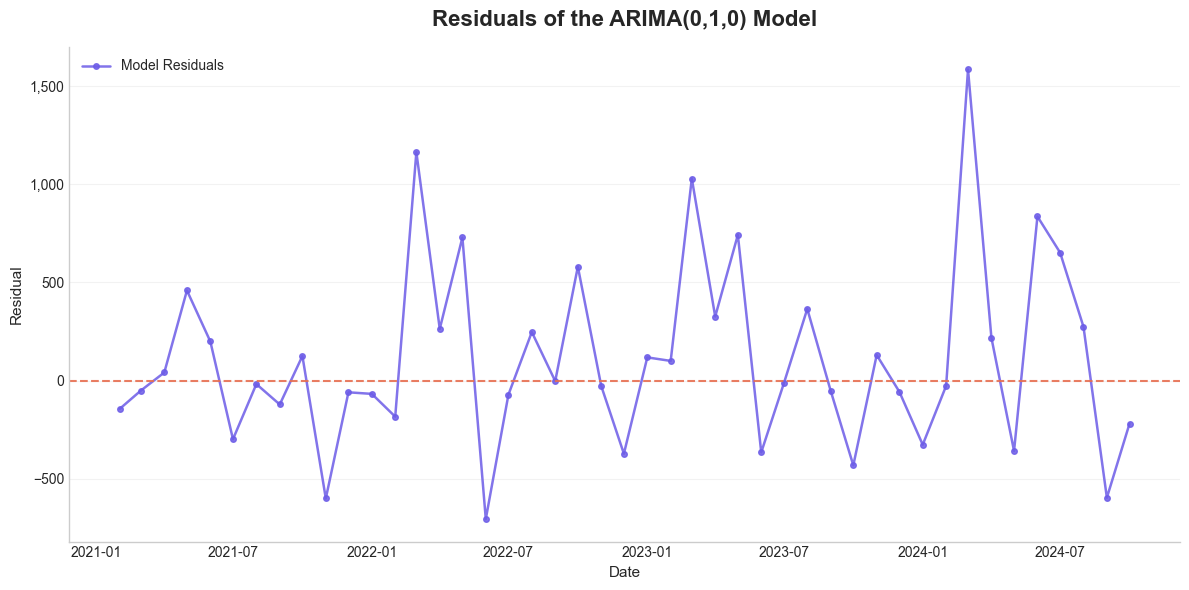

In [10]:
# Extract the in-sample residuals from the fitted model
residuals = model_fit.resid.iloc[1:]


# Visualise the residuals over time
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    residuals.index,
    residuals.values,
    label='Model Residuals',
    color='#6C5CE7',
    linewidth=1.8,
    marker='o',
    markersize=4,
    alpha=0.85
)

# Add a reference line representing zero residual error
ax.axhline(
    0,
    color='#E76F51',
    linestyle='--',
    linewidth=1.5,
    alpha=0.9
)

ax.set_title(
    'Residuals of the ARIMA(0,1,0) Model',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Residual', fontsize=11)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Residual Diagnostics

After estimating an ARIMA model, its residuals must be examined to determine whether the model has captured the systematic patterns in the time series. A residual is the difference between an observed value and the value fitted by the model:

$e_t=X_t-\hat{X}_t.$

where:

* $e_t$ is the residual at time $t$.
* $\hat{X}_t$ is the value of $X_t$ estimated or fitted by the ARIMA model at time $t$

A positive residual means that the observed value was higher than the fitted value, so the model underestimated the observation. A negative residual means that the observed value was lower than the fitted value, so the model overestimated it.

Residuals are sample-based estimates of the unobserved random errors. If the model has captured all systematic temporal patterns, the residuals should behave approximately like **white noise**. This means that they should satisfy three main conditions:

$E(e_t)=0,$

$\operatorname{Var}(e_t)=\sigma_e^2,$

and

$\operatorname{Cov}(e_t,e_{t-h})=0\quad\text{for }h>0.$

where:

* $\sigma_e^2$ is the constant variance of the residuals.

The first condition means that the residuals should fluctuate around zero. If their average is systematically positive or negative, the model consistently underestimates or overestimates the observed values.

The second condition means that the size of the residual fluctuations should remain approximately stable over time. If the residuals become progressively larger, the series may have changing variance, also called **heteroskedasticity**. A logarithmic or another variance-stabilising transformation may then be necessary.

The third condition means that the residuals should not remain correlated over time. If a positive residual is systematically followed by another positive residual, for example, the model has failed to capture part of the temporal dependence. Additional AR or MA terms may then be required.

A remaining trend in the residuals may indicate insufficient differencing, while repeated spikes at similar positions may suggest unmodelled seasonality. Individual unusually large residuals may indicate sudden shocks or outliers that the model could not predict.

### Residuals of the Hot Dog Sales Model

For the fitted $\operatorname{ARIMA}(0,1,0)$ model without drift, the fitted value for each period is the sales value observed in the previous month:

$\hat{X}_t=X_{t-1}.$

Therefore, except for the first observation, the residual is:

$e_t=X_t-\hat{X}_t=X_t-X_{t-1}=\Delta X_t.$

In this particular model, the residuals are therefore equal to the monthly changes in hot dog sales. A large positive residual represents an unexpectedly large monthly increase, while a large negative residual represents an unexpectedly large decrease.

For example, sales decreased from $2014$ units in January 2021 to $1870$ units in February 2021. The fitted value for February is the January value, so the residual is:

$e_{\text{Feb 2021}}=1870-2014=-144.$

The negative residual means that the model overestimated February sales by $144$ units.

A larger positive residual appears in March 2022, when sales increased from $1291$ to $2455$ units:

$e_{\text{Mar 2022}}=2455-1291=1164.$

The positive residual means that the model underestimated March sales by $1164$ units. Because $\operatorname{ARIMA}(0,1,0)$ contains no AR or MA terms, it could not predict this sudden increase from earlier changes or forecast errors.

The first residual in the graph is approximately $2014$, which is much larger than most subsequent residuals. This value should not be interpreted as an ordinary forecasting error. The first observation has no preceding month, so the model cannot calculate its fitted value in the usual way. The large initial residual is mainly a consequence of model initialisation and should be excluded from the substantive interpretation of the diagnostic plot.

After the first observation, the residuals generally fluctuate around the horizontal zero line. Positive and negative values alternate, and there is no clear sustained upward or downward trend. This suggests that first-order differencing successfully removed most of the systematic trend from the original hot dog sales series.

However, the graph also contains several large positive residuals, especially around the early parts of 2022, 2023 and 2024. The largest later positive residual is approximately $1600$ units. These repeated positive spikes may represent sudden sales increases, but their similar timing may also suggest a possible seasonal pattern that is not captured by the non-seasonal $\operatorname{ARIMA}(0,1,0)$ model.


**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 1.3.4 and 2.2, pp. 21–29 and 42–46, and Section 4.4, pp. 116–118. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 3.1, pp. 10–12.


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=523.715, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=525.675, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=525.684, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=523.211, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=527.504, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.278 seconds
Best ARIMA parameters: (0, 1, 0)


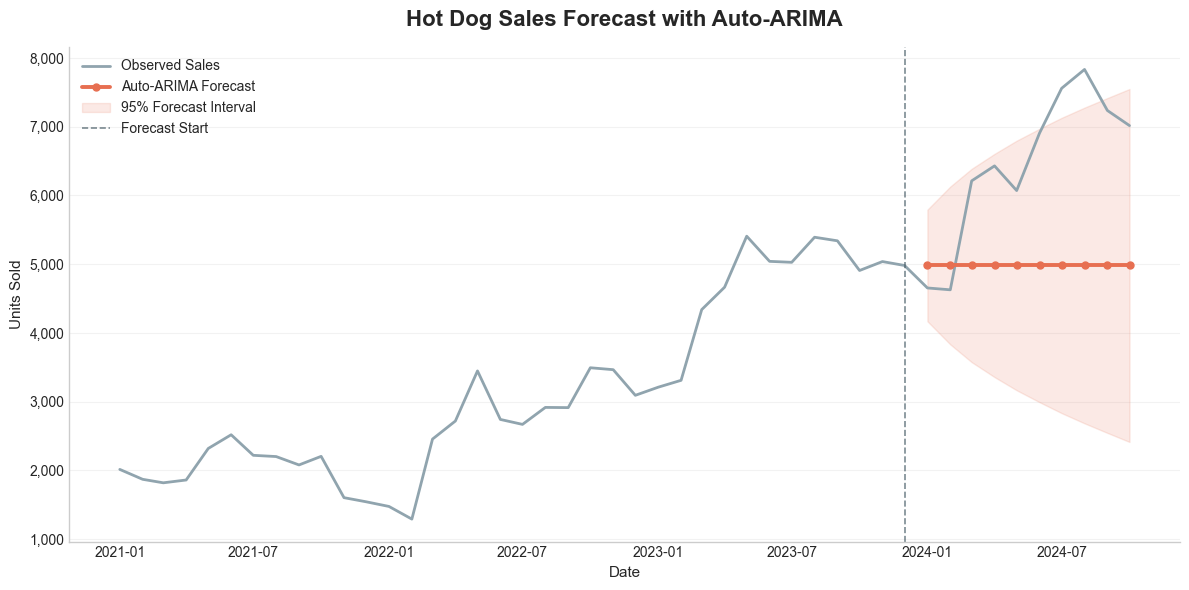

In [23]:
# -------------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings


# -------------------------------------------------------------------------
# Suppress warnings
# -------------------------------------------------------------------------
#
# Some candidate models may produce warnings during estimation, such as
# convergence problems or non-invertible parameter estimates. These warnings
# do not stop the model-selection procedure, so they are suppressed here.

warnings.filterwarnings('ignore')


# -------------------------------------------------------------------------
# Copy the data
# -------------------------------------------------------------------------
#
# Working with a copy preserves the original DataFrame.

df_auto_arima = df.copy()


# -------------------------------------------------------------------------
# Create the training and test sets
# -------------------------------------------------------------------------
#
# The first 80% of the observations are used for training and the final 20%
# for testing. Time-series observations are not randomly shuffled because
# their chronological order must be preserved.
#
# train: historical observations used to estimate the model
# test: later observations used to evaluate the forecasts

train_size = int(len(df_auto_arima['hot_dog_sales_pcs']) * 0.8)

train = df_auto_arima['hot_dog_sales_pcs'].iloc[:train_size]
test = df_auto_arima['hot_dog_sales_pcs'].iloc[train_size:]


# -------------------------------------------------------------------------
# Run Auto-ARIMA
# -------------------------------------------------------------------------
#
# auto_arima evaluates several ARIMA specifications and selects the model
# that performs best according to an information criterion.
#
# seasonal=False:
#   searches only for non-seasonal ARIMA models
#
# m=12:
#   represents a potential annual seasonal cycle in monthly data;
#   it has no practical effect when seasonal=False
#
# trace=True:
#   displays the candidate models evaluated during the search
#
# error_action='ignore':
#   skips candidate models that cannot be estimated
#
# suppress_warnings=True:
#   suppresses warnings generated during the Auto-ARIMA search

auto_arima_model = auto_arima(
    train,
    seasonal=False,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)


# -------------------------------------------------------------------------
# Display the selected model parameters
# -------------------------------------------------------------------------
#
# auto_arima_model.order returns the selected (p, d, q) specification:
#
# p = number of autoregressive terms
# d = order of differencing
# q = number of moving-average terms

print('Best ARIMA parameters:', auto_arima_model.order)


# -------------------------------------------------------------------------
# Forecast the test period
# -------------------------------------------------------------------------
#
# The number of forecast periods is set equal to the number of observations
# in the test set.
#
# forecast:
#   point forecasts for the test period
#
# conf_int:
#   lower and upper limits of the 95% forecast interval

forecast_steps = len(test)

forecast, conf_int = auto_arima_model.predict(
    n_periods=forecast_steps,
    return_conf_int=True
)


# -------------------------------------------------------------------------
# Convert the forecasts to a Pandas Series
# -------------------------------------------------------------------------
#
# Assigning the test index to the forecasts allows the predicted and observed
# values to be compared over the same dates.

forecast_series = pd.Series(
    forecast,
    index=test.index
)


# -------------------------------------------------------------------------
# Visualise the test-period forecasts
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))


# Plot the complete observed time series
ax.plot(
    df_auto_arima.index,
    df_auto_arima['hot_dog_sales_pcs'],
    label='Observed Sales',
    color='#90A4AE',
    linewidth=2
)


# Plot the forecast values
ax.plot(
    forecast_series.index,
    forecast_series.values,
    label='Auto-ARIMA Forecast',
    color='#E76F51',
    linewidth=2.8,
    marker='o',
    markersize=5
)


# Display the uncertainty associated with the forecasts
ax.fill_between(
    forecast_series.index,
    conf_int[:, 0],
    conf_int[:, 1],
    color='#E76F51',
    alpha=0.15,
    label='95% Forecast Interval'
)


# Mark the end of the training period
ax.axvline(
    x=train.index[-1],
    color='#455A64',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Forecast Start'
)


ax.set_title(
    'Hot Dog Sales Forecast with Auto-ARIMA',
    fontsize=16,
    fontweight='semibold',
    pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units Sold', fontsize=11)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', alpha=0.25, linewidth=0.8)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Automated ARIMA Selection and Holdout Evaluation

The manually selected $\operatorname{ARIMA}(0,1,0)$ model was based on the stationarity tests and the ACF and PACF plots. As an additional check, `auto_arima` can compare several candidate ARIMA specifications automatically.

However, selecting a model and evaluating its forecasting performance are two different tasks. Model selection is performed using the training data, while forecasting accuracy is evaluated using later observations that were not used to estimate the model.

### Chronological Training and Test Periods

The observations are divided chronologically into an $80$% training period and a $20$% test period.

The **training period** contains the earlier observations and is used to select and estimate the model. The **test period** contains the most recent observations and is used to evaluate how accurately the model forecasts genuinely unseen data.

The chronological split imitates a real forecasting situation:

* the model is estimated using only the information available up to the end of the training period;
* forecasts are produced for the following periods;
* those forecasts are compared with the actual observations in the test period.

### Automated Model Selection

The `auto_arima` procedure evaluates several combinations of $p$, $d$ and $q$ (in this project, `seasonal=False` means that only non-seasonal ARIMA models are considered).

The procedure uses a stepwise search. It begins with several candidate specifications and then explores nearby models that add or remove AR and MA terms. Candidate models that cannot be estimated successfully are skipped.

Each successfully estimated model is compared using the **Akaike Information Criterion**, abbreviated as **AIC**:

$\operatorname{AIC}=2k-2\ln(\hat{L}).$

where:

* $k$ is the number of parameters estimated in the candidate model;
* $\hat{L}$ is the maximised likelihood of the model;
* $\ln$ is the natural logarithm.

The $k$ used in the AIC formula represents the number of estimated model parameters. It should not be confused with the previously used $k$, which represented the forecast horizon.

The likelihood measures how well the model can reproduce the observed training data. A larger likelihood indicates better fit, so the term $-2\ln(\hat{L})$ becomes smaller when the model fits the data more closely.

The term $2k$ penalises model complexity. Adding more AR or MA parameters may improve the fit, but it also increases the penalty. The AIC therefore balances two objectives:

* fitting the training data well;
* avoiding an unnecessarily complicated model.

A smaller AIC indicates a more favourable balance between fit and complexity. The AIC has no meaningful interpretation in isolation; it is used to compare models estimated from the same data.

### Auto-ARIMA Example: Hot Dog Sales

The automated search evaluated several candidate models using the hot dog sales training period. Some of the reported AIC values were:

* $\operatorname{ARIMA}(0,1,0)$ without an intercept: $\operatorname{AIC}=523.211$;
* $\operatorname{ARIMA}(0,1,0)$ with an intercept: $\operatorname{AIC}=523.715$;
* $\operatorname{ARIMA}(1,1,0)$ with an intercept: $\operatorname{AIC}=525.675$;
* $\operatorname{ARIMA}(0,1,1)$ with an intercept: $\operatorname{AIC}=525.684$;
* $\operatorname{ARIMA}(1,1,1)$ with an intercept: $\operatorname{AIC}=527.504$.

The $\operatorname{ARIMA}(2,1,2)$ candidate produced an infinite AIC, meaning that the procedure could not obtain a valid finite estimate for that specification. It was therefore excluded from selection.

The smallest valid AIC was:

$\operatorname{AIC}=523.211,$

which belonged to:

$\operatorname{ARIMA}(0,1,0)$

without an intercept. The automated procedure therefore selected the same baseline model that was previously suggested by the stationarity, ACF and PACF analyses.

This agreement strengthens the justification for using $\operatorname{ARIMA}(0,1,0)$ as the initial specification. 
After selecting the model, $\operatorname{ARIMA}(0,1,0)$ is fitted only to the training period and used to forecast every observation in the test period. The vertical dashed line in the figure marks the end of the training data and the beginning of the holdout forecast.

The Auto-ARIMA point forecast remains approximately constant at $5000$ hot dogs throughout the test period. This occurs because the selected model is a random walk without drift. Its forecast for every future period is equal to the final observed training value:

$\hat{X}_{T+k\mid T}=X_T.$

The model therefore assumes that the expected future monthly change is zero. It allows sales to increase or decrease because of unpredictable shocks, but it cannot predict a systematic upward or downward movement.

The actual test observations initially remain close to the forecast, at approximately $4600$ to $5000$ units. However, sales subsequently increase above $6000$ units and eventually reach approximately $7600$ to $7800$ units. Most of the later observations are therefore substantially higher than the constant point forecast. The $95$% forecast interval becomes wider as the forecast horizon increasesb because of the accumulation of unknown future shocks. 


Because $e_{T+k}=X_{T+k}-\hat{X}_{T+k\mid T}$, this probability statement produces the approximate $95$% forecast interval:

$\hat{X}_{T+k\mid T}\pm1.96SE_k.$

**References:** Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Section 4.2.4, pp. 113–115, Section 4.3, pp. 115–116, and Section 4.5, pp. 118–119. Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 3.1, pp. 10–12, and Section 4.2, pp. 18–20.


In [27]:
# Evaluate the selected Auto-ARIMA model on the training and test periods

# -------------------------------------------------------------------
# TRAINING-PERIOD FITTED VALUES
# -------------------------------------------------------------------

# Generate in-sample fitted values for the training period
train_predictions = auto_arima_model.predict_in_sample()

train_prediction_series = pd.Series(
    np.asarray(train_predictions),
    index=train.index,
    name='Sales_predicted'
)

# Combine the observed and fitted training values
train_results = pd.DataFrame({
    'Sales': train,
    'Sales_predicted': train_prediction_series
})

# The first observations are used to initialise an integrated model.
# For d = 1, the first fitted value is therefore excluded.
d = auto_arima_model.order[1]

if d > 0:
    train_results = train_results.iloc[d:]

train_results = train_results.dropna()

# Forecast errors follow the convention:
# Error = observed sales - predicted sales
train_results['Error'] = (
    train_results['Sales']
    - train_results['Sales_predicted']
)


# -------------------------------------------------------------------
# TEST-PERIOD FORECASTS
# -------------------------------------------------------------------

# forecast_series was generated previously with:
# auto_arima_model.predict(n_periods=len(test))

test_results = pd.DataFrame({
    'Sales': test,
    'Sales_predicted': forecast_series
}).dropna()

test_results['Error'] = (
    test_results['Sales']
    - test_results['Sales_predicted']
)


# -------------------------------------------------------------------
# EVALUATION FUNCTION
# -------------------------------------------------------------------

def calculate_forecast_metrics(results):
    actual = results['Sales']
    predicted = results['Sales_predicted']
    errors = results['Error']

    # Mean Error: measures systematic forecast bias
    me = errors.mean()

    # Mean Squared Error
    mse = mean_squared_error(actual, predicted)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    # Mean Absolute Error
    mae = mean_absolute_error(actual, predicted)

    # Mean Absolute Percentage Error
    # Zero observations are excluded to avoid division by zero
    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100

    return pd.Series({
        'ME': me,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape
    })


# -------------------------------------------------------------------
# TRAIN–TEST COMPARISON
# -------------------------------------------------------------------

evaluation_results = pd.DataFrame({
    'Training period': calculate_forecast_metrics(train_results),
    'Test period': calculate_forecast_metrics(test_results)
}).T

display(evaluation_results.round(3))$95%$

,ME,MAE,MSE,RMSE,MAPE (%)
Training period,84.771,293.343,171763.743,414.444,10.004
Test period,1473.500,1609.700,3275102.100,1809.724,23.355


### Model Diagnostics and Forecast Accuracy

Model diagnostics and forecast-accuracy measures answer three related but different questions:

1. Do the residuals still contain a systematic temporal pattern?
2. How large are the model’s prediction errors?
3. Does an improvement in model fit justify additional model complexity?

Residual diagnostics address the first question, measures such as ME, MAE, MSE, RMSE and MAPE address the second, while information criteria such as AIC address the third.

The evaluation contains separate results for the training and test periods. Training-period measures are calculated from values used to estimate the model and may therefore provide an optimistic assessment. Test-period measures are more important because they show how accurately the model predicts later observations that were not used during estimation.

The forecast error has already been defined as:

$e_t=X_t-\hat{X}_t.$

A positive error means that the observed value is higher than the prediction, so the model has underestimated sales. A negative error means that the prediction is higher than the observed value, so the model has overestimated sales.

In the following formulas, $n$ is the number of observations included in the evaluation. The test period contains $10$ monthly observations.

#### Mean Error

The Mean Error, abbreviated as ME, is the average of the signed forecast errors:

$\operatorname{ME}=\frac{1}{n}\sum_{t=1}^{n}e_t.$

The sign of ME indicates the direction of the model’s bias:

* if $\operatorname{ME}>0$, the model systematically underestimates the observed values;
* if $\operatorname{ME}<0$, the model systematically overestimates them;
* if $\operatorname{ME}\approx0$, there is no clear average directional bias.

The principal advantage of ME is that it shows whether predictions are systematically too high or too low. Its main limitation is that positive and negative errors may cancel each other. For example, if the errors are $-100$ and $100$, their mean is zero even though neither prediction is accurate.

For the training period, the result is:

$\operatorname{ME}_{train}=84.771.$

This positive but relatively small value indicates that the fitted values underestimated monthly hot dog sales by approximately $85$ units on average during the training period.

For the test period:

$\operatorname{ME}_{test}=1473.500.$

Because the test set contains $10$ observations, this result was calculated as:

$\operatorname{ME}_{test}=\frac{1}{10}\sum_{t=1}^{10}e_t=1473.500.$

Consequently, the sum of the signed test errors is:

$\sum_{t=1}^{10}e_t=10(1473.500)=14735.$

The positive result means that observed test-period sales were, on average, approximately $1474$ hot dogs higher than the model’s forecasts. The model therefore shows substantial systematic underprediction during the test period.

However, ME alone cannot determine the overall accuracy of the forecasts because errors with opposite signs may offset each other. Error magnitude must therefore also be measured using MAE, MSE or RMSE.

#### Mean Absolute Error

The Mean Absolute Error, abbreviated as MAE, is the average absolute size of the forecast errors:

$\operatorname{MAE}=\frac{1}{n}\sum_{t=1}^{n}|e_t|.$

The absolute value $|e_t|$ removes the direction of the error. Therefore, an error of $-500$ and an error of $500$ both contribute $500$ units to MAE.

MAE is easy to interpret because it is expressed in the original unit of the target variable. In this project, it shows the average number of hot dogs by which predictions differ from observed sales. It also treats every additional unit of error equally. Its limitation is that it does not penalise occasional very large errors as strongly as MSE or RMSE.

For the training period:

$\operatorname{MAE}_{train}=293.343.$

The fitted training values therefore differed from observed monthly sales by approximately $293$ hot dogs on average.

For the test period:

$\operatorname{MAE}_{test}=1609.700.$

This means that the test-period predictions differed from observed monthly sales by approximately $1610$ hot dogs on average, regardless of whether the model overestimated or underestimated them.

The test MAE is approximately:

$\frac{1609.700}{293.343}\approx5.49$

times the training MAE. Therefore, the model performed substantially worse on new observations than on the data used for estimation.

The test ME of $1473.500$ is also close to the test MAE of $1609.700$. This shows that most of the total forecast error occurred in the same direction: the model generally underestimated the later hot dog sales rather than producing equally large overestimations and underestimations.

#### Mean Squared Error

The Mean Squared Error, abbreviated as MSE, is the average of the squared forecast errors:

$\operatorname{MSE}=\frac{1}{n}\sum_{t=1}^{n}e_t^2.$

Squaring the errors has two effects. First, negative and positive errors cannot cancel each other. Second, large errors receive disproportionately greater weight. For example:

$500^2=250000,$

whereas:

$1000^2=1000000.$

Thus, doubling an error increases its contribution to MSE by a factor of four.

The advantage of MSE is that it strongly penalises models that make occasional large mistakes. It is also closely connected to maximum likelihood estimation when the model errors are assumed to follow a normal distribution. Its main disadvantages are its sensitivity to extreme errors and its squared unit of measurement. Because sales are measured in hot dogs, MSE is measured in squared hot dogs and cannot be interpreted directly as an average number of incorrectly predicted units.

For the training period:

$\operatorname{MSE}_{train}=171763.743.$

For the test period:

$\operatorname{MSE}_{test}=3275102.100.$

Because there are $10$ test observations:

$\operatorname{MSE}_{test}=\frac{1}{10}\sum_{t=1}^{10}e_t^2=3275102.100.$

The total squared test error is therefore:

$\sum_{t=1}^{10}e_t^2=10(3275102.100)=32751021.$

The test MSE is approximately $19.07$ times the training MSE. This large increase shows that the model produced much larger errors during the test period. 

#### Root Mean Squared Error

The Root Mean Squared Error, abbreviated as RMSE, is the square root of MSE:

$\operatorname{RMSE}=\sqrt{\operatorname{MSE}}=\sqrt{\frac{1}{n}\sum_{t=1}^{n}e_t^2}.$

RMSE retains the strong penalty assigned to large errors by MSE but converts the result back to the original measurement unit. It can therefore be interpreted in hot dogs rather than squared hot dogs.

The disadvantage of RMSE is that it remains sensitive to unusually large errors. A few months with exceptionally inaccurate forecasts can increase RMSE considerably. For this reason, RMSE should be interpreted together with MAE.

For the training period:

$\operatorname{RMSE}_{train}=\sqrt{171763.743}=414.444.$

The model’s training errors therefore had a magnitude of approximately $414$ hot dogs on the RMSE scale.

For the test period:

$\operatorname{RMSE}_{test}=\sqrt{3275102.100}=1809.724.$

The test RMSE is approximately:

$\frac{1809.724}{414.444}\approx4.37$

times the training RMSE. The model’s out-of-sample forecast errors were therefore much larger than its in-sample fitting errors.

The test RMSE of $1809.724$ is greater than the test MAE of $1609.700$. This is expected because RMSE gives greater weight to the largest errors. The difference between the two measures suggests that some test months had particularly large forecast errors, although the high MAE shows that poor performance was not limited to only one observation.

Because RMSE is the square root of MSE, MSE and RMSE always rank competing models in the same order when they are calculated from the same observations.

#### Mean Absolute Percentage Error

The Mean Absolute Percentage Error, abbreviated as MAPE, expresses the average absolute forecast error as a percentage of the observed values:

$\operatorname{MAPE}=\frac{100}{n}\sum_{t=1}^{n}\left|\frac{e_t}{X_t}\right|.$

The main advantage of MAPE is that it is independent of the original measurement scale. A MAPE of $10$% has the same general interpretation whether the target variable represents hot dogs, customers or revenue. This makes it useful for comparing forecast accuracy across series with different units or levels.

However, MAPE cannot be calculated when an observed value is zero, and observations close to zero can produce extremely large percentage errors. It can also penalise overprediction and underprediction asymmetrically. These problems are not substantial in the present project because all observed hot dog sales values are positive and far from zero.

For the training period:

$\operatorname{MAPE}_{train}=10.004.$

The fitted training values therefore differed from observed sales by approximately $10.0$% on average.

For the test period:

$\operatorname{MAPE}_{test}=23.355.$%

The test forecasts differed from observed sales by approximately $23.4$% on average. This is approximately $2.33$ times the training MAPE, providing further evidence that the model did not generalise well to the later period.

#### Combined Interpretation

| Measure | Training period |   Test period | Main interpretation                                  |
| ------- | --------------: | ------------: | ---------------------------------------------------- |
| ME      |        $84.771$ |    $1473.500$ | Strong test-period underprediction                   |
| MAE     |       $293.343$ |    $1609.700$ | Average test error of approximately $1610$ hot dogs  |
| MSE     |    $171763.743$ | $3275102.100$ | Large test errors receive a strong penalty           |
| RMSE    |       $414.444$ |    $1809.724$ | Test errors are much larger than training errors     |
| MAPE    |       $10.004$% |     $23.355$% | Average relative test error of approximately $23.4$% |

All error-magnitude measures indicate a substantial deterioration from the training period to the test period. The positive test ME also shows that this deterioration is not caused only by random errors in both directions. The model systematically underestimated the later sales values.

This result is consistent with the forecast graph. The selected ARIMA$(0,1,0)$ model without drift produced an approximately constant forecast close to the final training observation, while actual hot dog sales increased considerably during the test period. The model captured the earlier observations reasonably well but could not reproduce the later upward movement.
As we showed in this project the lowest AIC does not guarantee the most accurate future forecasts. 
The results therefore suggest comparing the baseline model with alternatives that include drift, seasonal components or other low-order AR and MA terms. Nevertheless, the test set contains only $10$ observations, so the exact values of the accuracy measures should be interpreted cautiously and ideally confirmed through rolling-origin time-series validation.

**References:** Zemkoho, A. (2023). “A Basic Time Series Forecasting Course with Python.” *Operations Research Forum*, 4(2), Section 3.1, pp. 10–12. Huang, C., and Petukhina, A. (2022). *Applied Time Series Analysis and Forecasting with Python*. Springer, Sections 4.4–4.5, pp. 116–119.
